# Import Libraries & Load the Data

In [61]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [62]:
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\SweetShop_2020_to_2025_Nov_Data (1).xlsx")

In [63]:
df.head()

,Date,Branch,Product,Qty,TotalAmount
0,2020-01-01,Main Branch,Kaju Katli,19,6384
1,2020-01-01,Main Branch,Jalebi,49,9212
2,2020-01-01,Main Branch,Ladoo,48,11472
3,2020-01-01,Main Branch,Pedha,48,15696
4,2020-01-01,Main Branch,Barfi,46,13064


# Inspection of Data

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32415 entries, 0 to 32414
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         32415 non-null  datetime64[ns]
 1   Branch       32415 non-null  object        
 2   Product      32415 non-null  object        
 3   Qty          32415 non-null  int64         
 4   TotalAmount  32415 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 1.2+ MB


In [65]:
df.shape

(32415, 5)

In [66]:
df.describe()

,Date,Qty,TotalAmount
count,32415,32415.000000,32415.000000
mean,2022-12-15 23:59:59.999999744,44.003579,10987.350979
min,2020-01-01 00:00:00,15.000000,2250.000000
25%,2021-06-24 00:00:00,29.000000,6718.000000
50%,2022-12-16 00:00:00,42.000000,9800.000000
75%,2024-06-08 00:00:00,52.000000,13677.000000
max,2025-11-30 00:00:00,334.000000,112880.000000
std,NaN,25.196333,7039.564029


In [67]:
df.isnull().sum()

Date           0
Branch         0
Product        0
Qty            0
TotalAmount    0
dtype: int64

In [68]:
df.duplicated().any()

False

In [69]:
df = df.rename(columns={"TotalAmount": "Sales"})

# Feature Engineering

In [70]:
df["Date"].nunique()

2161

In [71]:
df["Date"].isna().sum()

0

In [72]:
df["Month"] = df["Date"].dt.month_name()
df["Month"] 

0         January
1         January
2         January
3         January
4         January
           ...   
32410    November
32411    November
32412    November
32413    November
32414    November
Name: Month, Length: 32415, dtype: object

In [73]:
df["Week"] = df['Date'].dt.isocalendar().week

In [74]:
df['Date'] = pd.to_datetime(df['Date'])
df['Weekday'] = df['Date'].dt.dayofweek
df['Weekend'] = df['Weekday'].isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})


In [75]:
weekend_sales = (df.groupby('Weekend')['Sales'].sum().reset_index())
weekday_sales = (df.groupby('Weekday')['Sales'].sum().reset_index())

In [76]:
weekend_ = df.groupby('Weekend')['Sales'].sum()

# Identify weekend patterns

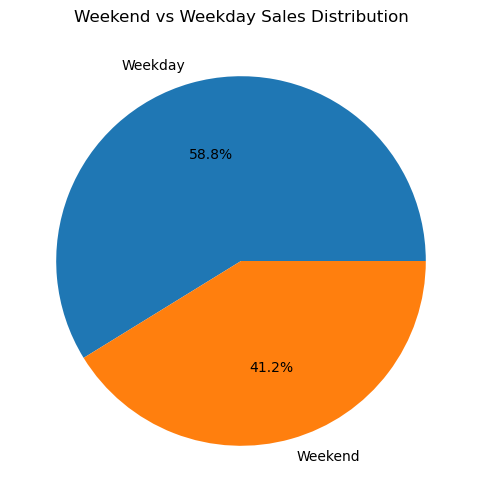

In [77]:
#Identify weekend patterns

labels = weekend_sales['Weekend']
sizes = weekend_sales['Sales']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Weekend vs Weekday Sales Distribution")
plt.show()


# Diwali Sales Over Month of October and November in each year

In [78]:
diwali = df[df['Date'].dt.month.isin([10,11])]
diwali_sales = diwali.groupby(diwali['Date'].dt.year)['Sales'].sum()
diwali_sales

Date
2020    10601352
2021    10432032
2022    10254827
2023    10762633
2024    10499698
2025    10832820
Name: Sales, dtype: int64

# Diwali Sales in Diwali week Year Wise

In [79]:
diwali_days = [
    ("2020-11-12","2020-11-16"),
    ("2021-11-02","2021-11-06"),
    ("2022-10-22","2022-10-26"),
    ("2023-11-10","2023-11-14"),
    ("2024-11-01","2024-11-05"),
    ("2025-10-20","2025-10-24")]

diwali_df = pd.concat([
    df[(df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))]
    for start, end in diwali_days
])

diwali_sales = diwali_df.groupby(diwali_df['Date'].dt.year)['Sales'].sum().reset_index()
diwali_sales

,Date,Sales
0,2020,1670859
1,2021,1402156
2,2022,1527365
3,2023,1711505
4,2024,1649522
5,2025,1429023


# Rakshabandhan Sales in Month of August

In [80]:
# Sales over month of rakhi in every every year 
rakhi = df[df['Date'].dt.month == 8]
rakhi_sales = rakhi.groupby(rakhi['Date'].dt.year)['Sales'].sum()
rakhi_sales

Date
2020    5695882
2021    5825195
2022    5505055
2023    5495105
2024    5684761
2025    5198146
Name: Sales, dtype: int64

# Rakshabandhan Sales in that week of August year wise

In [81]:
rakhi_days = [
    ("2020-08-01","2020-08-05"),
    ("2021-08-19","2021-08-23"),
    ("2022-08-09","2022-08-13"),
    ("2023-08-28","2023-09-01"),
    ("2024-08-17","2024-08-21"),
    ("2025-08-06","2025-08-10")
]

rakhi_df = pd.concat([
    df[(df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))]
    for start, end in rakhi_days
])

rakhi_sales = rakhi_df.groupby(rakhi_df['Date'].dt.year)['Sales'].sum().reset_index()
rakhi_sales

,Date,Sales
0,2020,1495148
1,2021,1813169
2,2022,1471810
3,2023,1376353
4,2024,1623748
5,2025,855572


# Sankranti Sales in Month of January in each year

In [82]:
# Sales over month of sankranti in every every year 
sankranti = df[df['Date'].dt.month == 1]
sankranti_sales = rakhi.groupby(rakhi['Date'].dt.year)['Sales'].sum()
sankranti_sales

Date
2020    5695882
2021    5825195
2022    5505055
2023    5495105
2024    5684761
2025    5198146
Name: Sales, dtype: int64

# Sankranti Sales over a week of january

In [83]:
sankranti_days = [
    ("2020-01-12","2020-01-16"),
    ("2021-01-12","2021-01-16"),
    ("2022-01-12","2022-01-16"),
    ("2023-01-12","2023-01-16"),
    ("2024-01-12","2024-01-16"),
    ("2025-01-12","2025-01-16")
]

sankranti_df = pd.concat([
    df[(df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))]
    for start, end in sankranti_days
])

sankranti_sales = sankranti_df.groupby(sankranti_df['Date'].dt.year)['Sales'].sum().reset_index()
sankranti_sales

,Date,Sales
0,2020,1534772
1,2021,1502082
2,2022,1477718
3,2023,1518676
4,2024,1531402
5,2025,1521501


# Month wise Sales

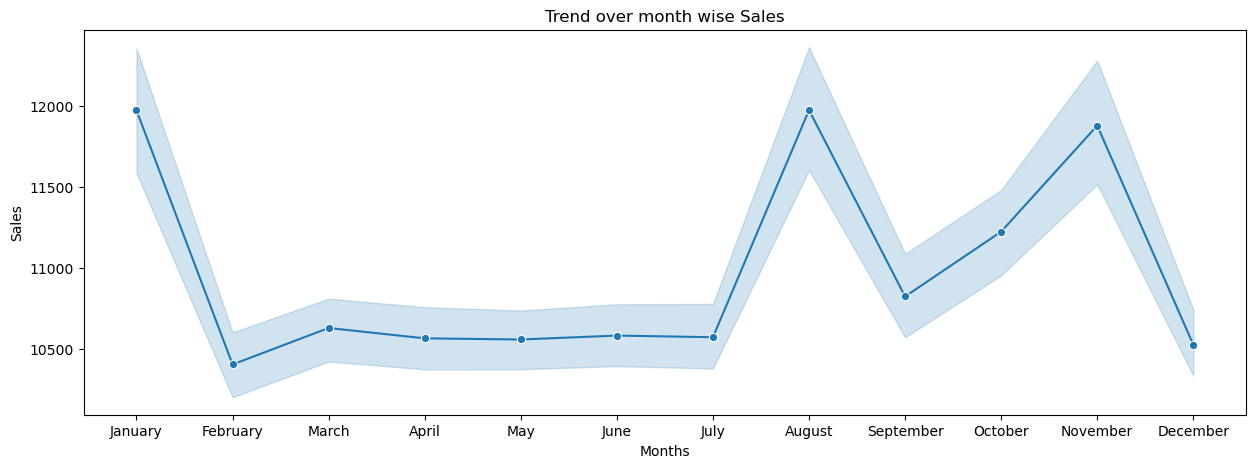

In [84]:
plt.figure(figsize=(15,5))
sns.lineplot(df,x = "Month",y ="Sales",marker="o")
plt.title("Trend over month wise Sales")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18296\2863356515.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Week', y='Sales', ci=None, palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18296\2863356515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Week', y='Sales', ci=None, palette='viridis')


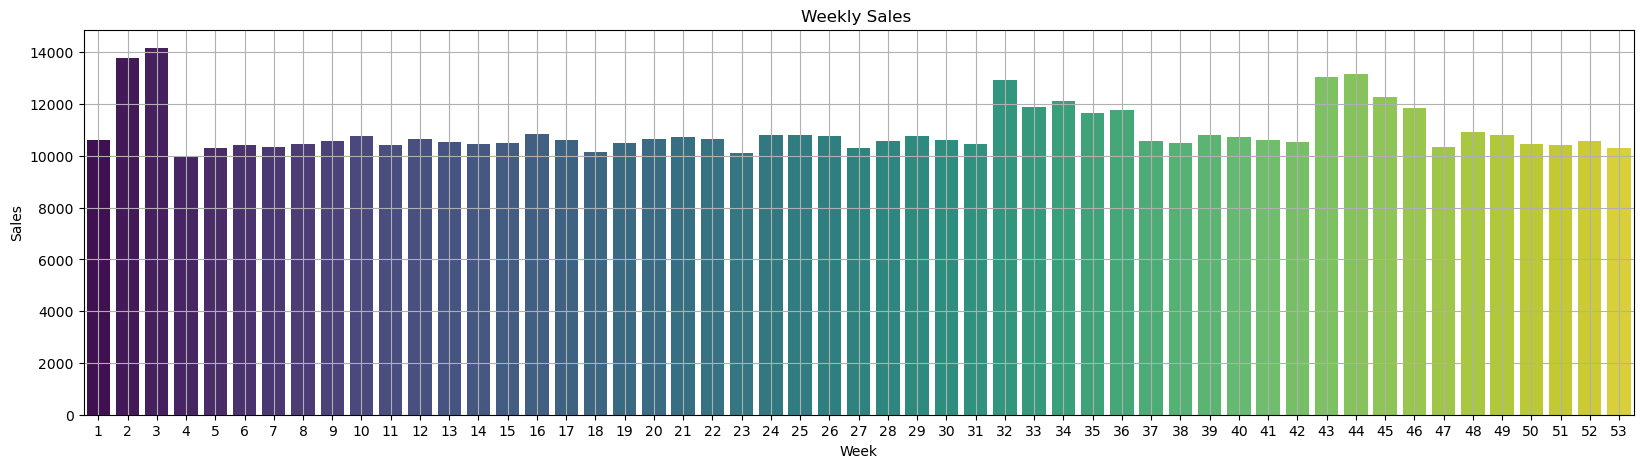

In [85]:
# Weekley Sales
plt.figure(figsize=(20,5))
sns.barplot(data=df, x='Week', y='Sales', ci=None, palette='viridis')
plt.title("Weekly Sales ")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid()
plt.show()


# product wise Sales

C:\Users\DELL\AppData\Local\Temp\ipykernel_18296\3112740243.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Product', y='Sales', ci=None, palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18296\3112740243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product', y='Sales', ci=None, palette='viridis')


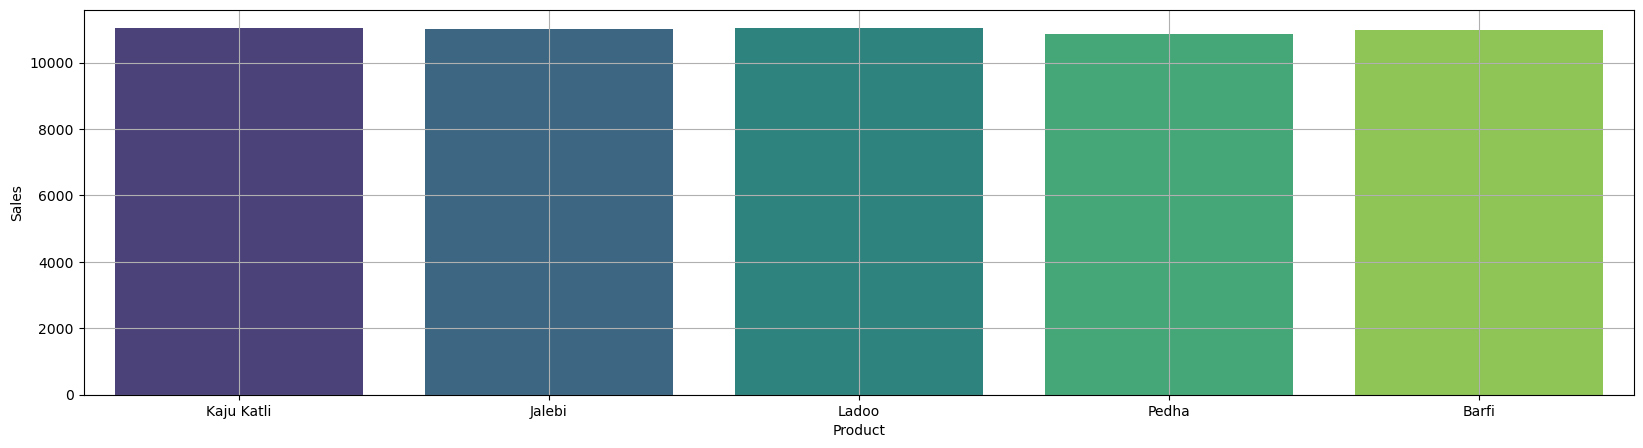

In [86]:
plt.figure(figsize=(20,5))
sns.barplot(data=df, x='Product', y='Sales', ci=None, palette='viridis')
plt.grid()
plt.show()

# Branch wise Sales

C:\Users\DELL\AppData\Local\Temp\ipykernel_18296\1768856149.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Branch', y='Sales', ci=None, palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18296\1768856149.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Branch', y='Sales', ci=None, palette='viridis')


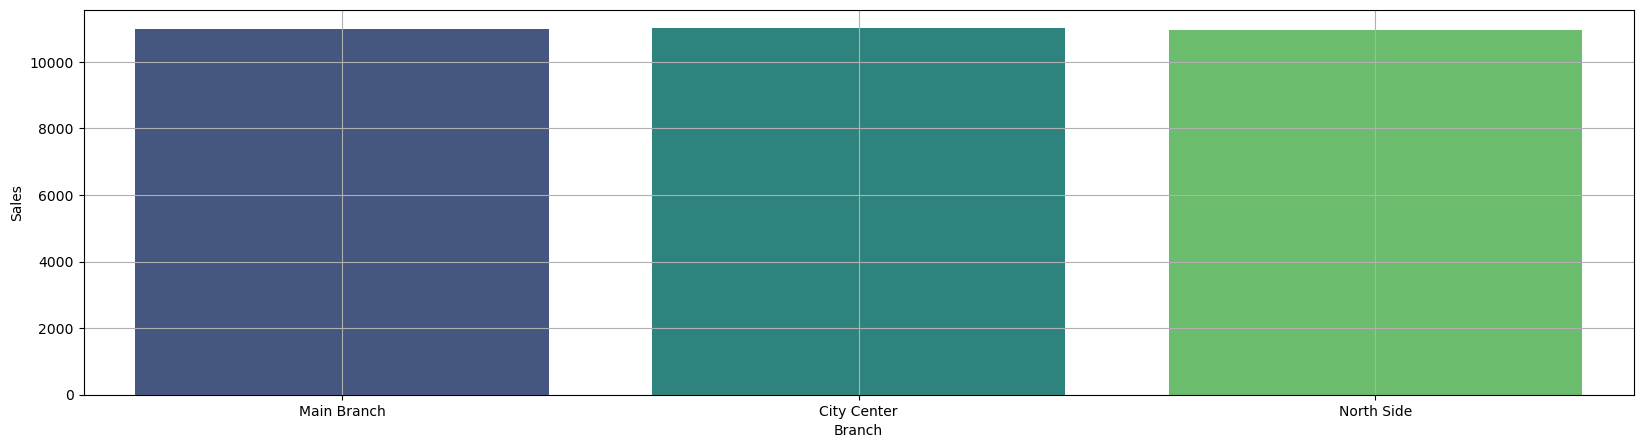

In [87]:
plt.figure(figsize=(20,5))
sns.barplot(data=df, x='Branch', y='Sales', ci=None, palette='viridis')
plt.grid()
plt.show()

#  ML Models for Forcasting

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from datetime import timedelta

In [89]:
le_branch = LabelEncoder()
le_product = LabelEncoder()

df['Branch_encoded'] = le_branch.fit_transform(df['Branch'])  
df['Product_encoded'] = le_product.fit_transform(df['Product'])  


In [90]:
df['month'] = df['Date'].dt.month        
df['day'] = df['Date'].dt.day         
df['dayofweek'] = df['Date'].dt.dayofweek 
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)  
df['week'] = df['Date'].dt.isocalendar().week 


In [91]:
features = ['Branch_encoded', 'Product_encoded', 'month', 'day', 'dayofweek', 'is_weekend', 'week', 'Qty']
X = df[features].values  
y = df['Sales'].values 

In [92]:
le_branch = LabelEncoder()
le_product = LabelEncoder()

df['Branch_encoded'] = le_branch.fit_transform(df['Branch']) 
df['Product_encoded'] = le_product.fit_transform(df['Product']) 


In [93]:
features = ['Branch_encoded', 'Product_encoded', 'month', 'day', 'dayofweek', 'is_weekend', 'week', 'Qty']
X = df[features].values 
y = df['Sales'].values  


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [95]:
class DecisionTree:
    def __init__(self):
        pass
    
    def fit(self, X, y):
        self.value = np.mean(y) 
    
    def predict(self, X):
        return np.full(len(X), self.value)

In [96]:
class RandomForest:
    def __init__(self, n_trees=10):
        self.n_trees = n_trees
        self.trees = []
    
    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_trees):
            
            tree = DecisionTree()
            tree.fit(X, y)
            self.trees.append(tree)
        print(f"Trained {self.n_trees} trees!")
    
    def predict(self, X):
        predictions = []
        for tree in self.trees:
            pred = tree.predict(X)
            predictions.append(pred)
        return np.mean(predictions, axis=0)

In [97]:
rf = RandomForest(n_trees=10)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

Trained 10 trees!


In [98]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"Test MAE: {mae:.2f}")
print(f"Test R²: {r2:.3f}")

Test MAE: 4428.16
Test R²: -0.000


In [99]:
print("Actual sales:", y_test[:10])
print("Predicted sales:", y_pred_test[:10])


Actual sales: [ 8946  8526  6630  8160  4995 12411 11500  5886  5670 12654]
Predicted sales: [10969.61661268 10969.61661268 10969.61661268 10969.61661268
 10969.61661268 10969.61661268 10969.61661268 10969.61661268
 10969.61661268 10969.61661268]


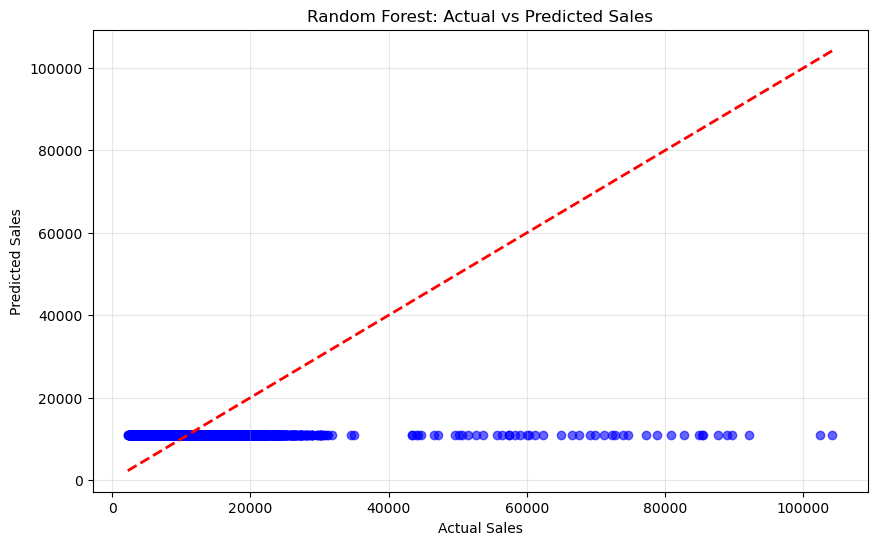

In [100]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line shows perfect prediction
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Random Forest: Actual vs Predicted Sales')
plt.grid(True, alpha=0.3)
plt.show()

# prediction for next Year

In [57]:
# Extract day, month, and year from the date
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year


In [58]:
all_forecasts =[]

In [110]:
for product, data in df.groupby('Product'):
    data = data.copy()

    # Make sure there is enough data to train
    if len(data) < 10:  # skip very small products
        print(f"Skipping product {product}, not enough data")
        continue


In [111]:
features = ['day', 'month', 'year']

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(data[features], data['Sales'])

# Predict historical sales (optional)
data['Forecast_Sales'] = model.predict(data[features])

In [112]:
# Predict next 365 days
last_date = data['Date'].max()
future_dates = [last_date + timedelta(days=i) for i in range(1, 366)]
future_df = pd.DataFrame({'Date': future_dates})
future_df['day'] = future_df['Date'].dt.day
future_df['month'] = future_df['Date'].dt.month
future_df['year'] = future_df['Date'].dt.year
future_df['Product'] = product

In [113]:
# Predict future sales
future_df['Forecast_Sales'] = model.predict(future_df[features])

# Combine historical + future
combined = pd.concat([data, future_df], ignore_index=True)
all_forecasts.append(combined)


In [114]:
# Combine all products
final_df = pd.concat(all_forecasts, ignore_index=True)

# Save result
final_df.to_csv('Productwise_365day_Forecast.csv', index=False)
final_df.tail()


,Date,Branch,Product,Qty,Sales,Month,Week,Weekday,Weekend,Branch_encoded,Product_encoded,month,day,dayofweek,is_weekend,week,year,Forecast_Sales
41083,2026-11-26,NaN,Pedha,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,11,26,NaN,NaN,<NA>,2026,7576.078512
41084,2026-11-27,NaN,Pedha,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,11,27,NaN,NaN,<NA>,2026,11927.771048
41085,2026-11-28,NaN,Pedha,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,11,28,NaN,NaN,<NA>,2026,7180.133929
41086,2026-11-29,NaN,Pedha,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,11,29,NaN,NaN,<NA>,2026,15983.908071
41087,2026-11-30,NaN,Pedha,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,11,30,NaN,NaN,<NA>,2026,12760.903143


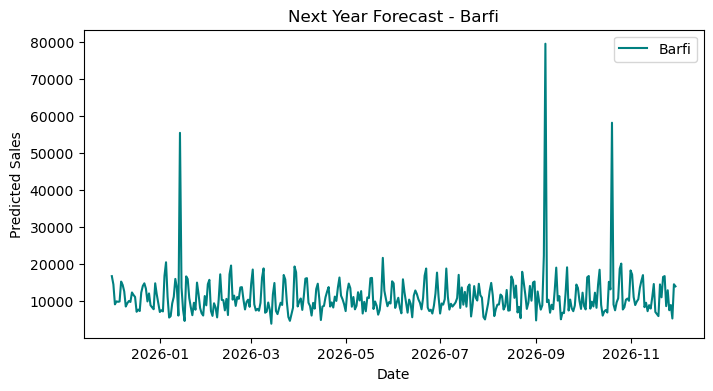

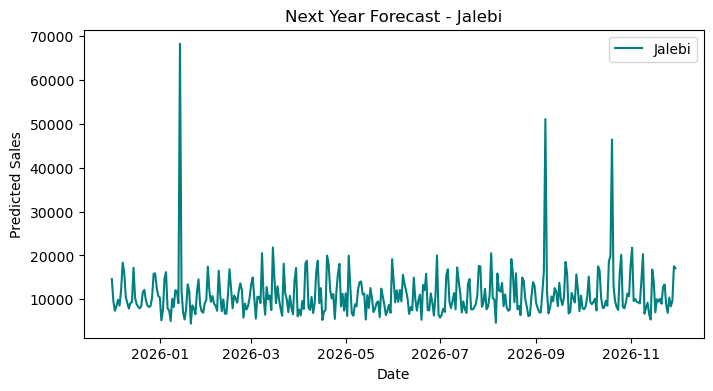

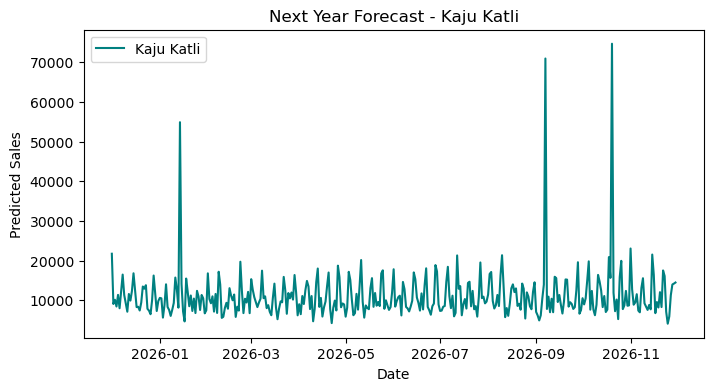

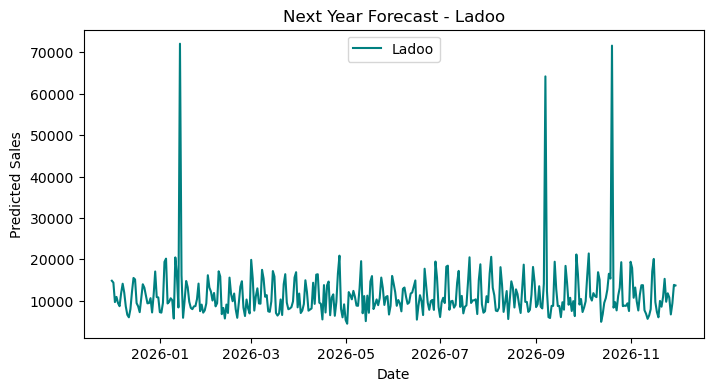

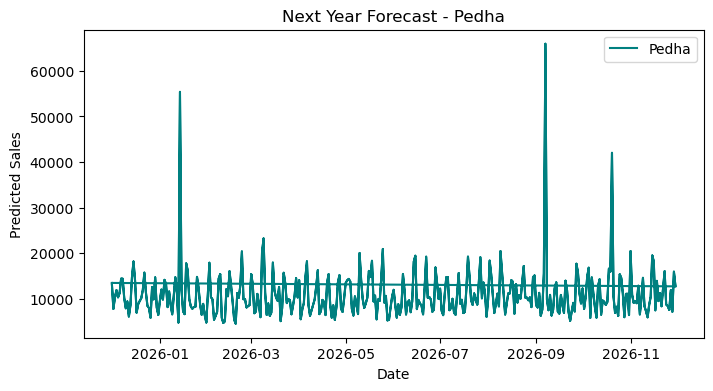

In [115]:
# Filter only next year's forecast data
last_date = df['Date'].max()
future_data = final_df[final_df['Date'] > last_date]

# Plot product-wise forecast
for product in future_data['Product'].unique():
    data = future_data[future_data['Product'] == product]
    plt.figure(figsize=(8,4))
    plt.plot(data['Date'], data['Forecast_Sales'], label=product, color='teal')
    plt.title(f"Next Year Forecast - {product}")
    plt.xlabel("Date")
    plt.ylabel("Predicted Sales")
    plt.legend()
    plt.show()


# XGBoost Model 

In [51]:
import xgboost as xgb

In [52]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,    
    max_depth=6,        
    learning_rate=0.1,     
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [53]:
# Predict
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
r2_xgb = r2_score(y_test, y_pred_test_xgb)


In [54]:
print(mae_xgb)

2250.0689964453304


In [55]:
print(r2_xgb)

0.8015217185020447



# Comparison

In [56]:
print(mae-mae_xgb)   #difference is of approrximatly 2100

2178.088578490091
